# Real-Time Credit Card Fraud Detection and Risk Scoring System
Business Problem: Financial institutions lose billions annually due to fraudulent transactions. Traditional rule-based systems generate a high number of false positives, leading to customer dissatisfaction and operational costs.

The objective is to predict whether a transaction is fraudulent and generate a real-time fraud risk score.

In [2]:
# ============================================================================
# SECTION 1: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================================
# SECTION 2: DATA LOADING AND INITIAL EXPLORATION
# ============================================================================
filepath = r"~\Proj\creditcard.csv"
df = pd.read_csv(filepath)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df['Class'].value_counts()
# 0- non fraud,1 - fraud

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

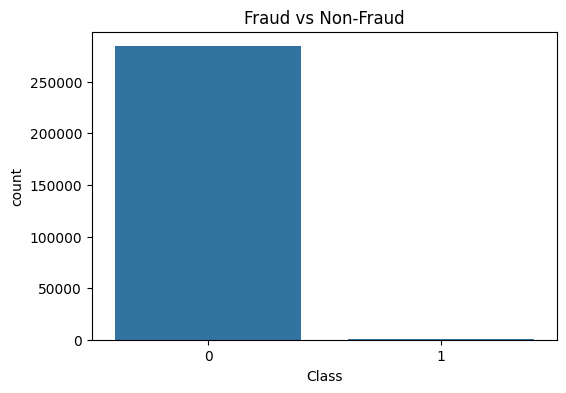

In [10]:
# Fraud Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Non-Fraud")
plt.show()

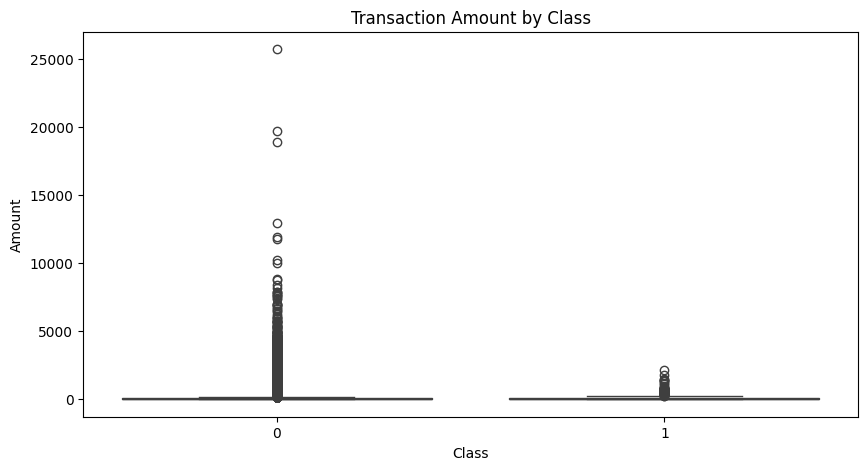

In [11]:
# Transaction Amount Analysis
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Transaction Amount by Class")
plt.show()

Analysis of transaction amounts revealed that fraudulent transactions were generally concentrated in lower transaction value ranges, whereas legitimate transactions exhibited significantly higher transaction amounts. This indicates that transaction amount alone is not a reliable predictor of fraud and reinforces the need for machine learning models that consider multiple behavioral and transactional features simultaneously.

In [13]:
fraud = df[df['Class']==1]['Amount']
nonfraud = df[df['Class']==0]['Amount']

summary = pd.DataFrame({
    'Fraud': fraud.describe(),
    'Non_Fraud': nonfraud.describe()
})

print(summary)

             Fraud      Non_Fraud
count   492.000000  284315.000000
mean    122.211321      88.291022
std     256.683288     250.105092
min       0.000000       0.000000
25%       1.000000       5.650000
50%       9.250000      22.000000
75%     105.890000      77.050000
max    2125.870000   25691.160000


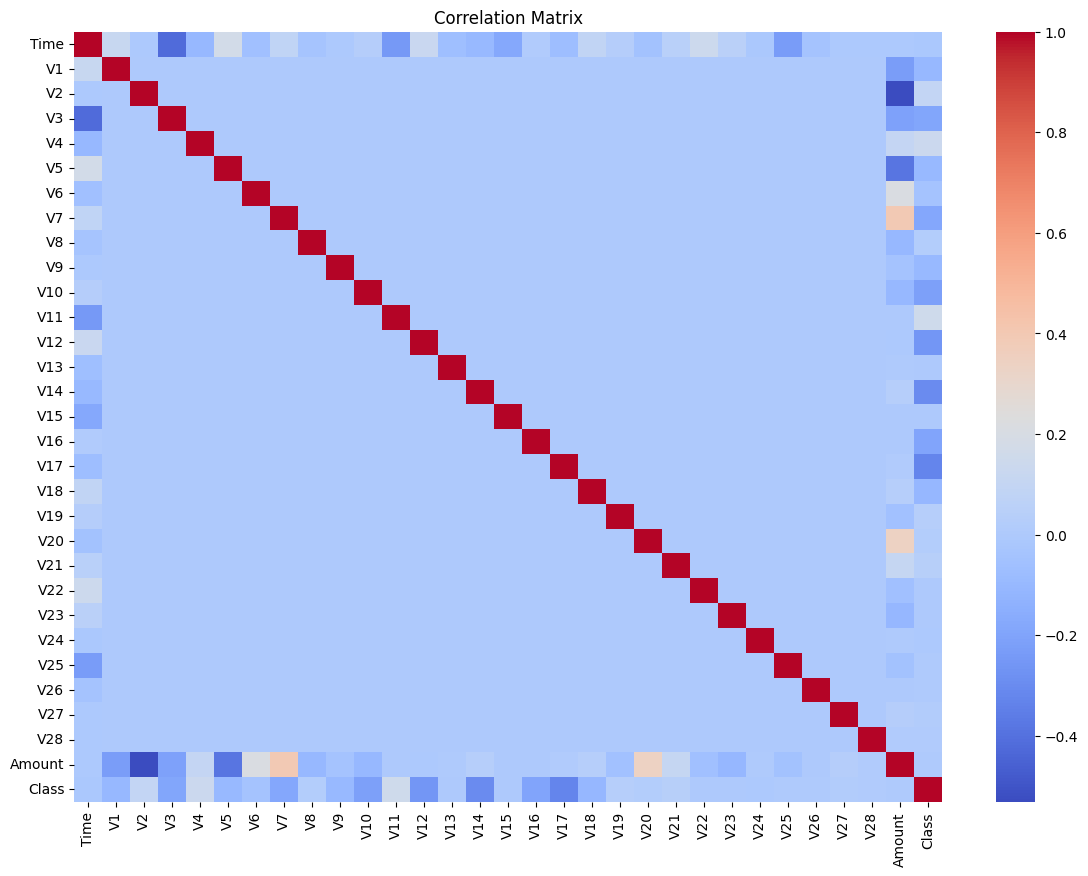

In [14]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

To protect customer privacy and banking confidentiality, the dataset creators transformed the original variables using PCA(V1-V28).we can't interpret the variables directly,as we don't know the mapping of V1-V28.Consequently, individual feature interpretation is limited, and the project focuses primarily on predictive performance and fraud detection rather than business-level feature explanations.

In [16]:
# ============================================================================
# TRAIN-TEST SPLIT - Feature & Target Split
# ============================================================================
X = df.drop('Class', axis=1)

y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
# Standardization - Amount & Time
scaler = StandardScaler()

X_train[['Amount','Time']] = scaler.fit_transform(
    X_train[['Amount','Time']]
)

X_test[['Amount','Time']] = scaler.transform(
    X_test[['Amount','Time']]
)

In [18]:
# ============================================================================
# HANDLE IMBALANCE Using SMOTE
# ============================================================================

print("Before SMOTE")

print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


In [19]:
# ============================================================================
# LOGISTIC REGRESSION
# ============================================================================
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [20]:
# LR evaluation
print("Logistic Regression classification_report:\n",
    classification_report(
    y_test,
    lr_pred
))

print("confusion_matrix:\n",
    confusion_matrix(
    y_test,
    lr_pred
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        lr_prob
    )
)

Logistic Regression classification_report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

confusion_matrix:
 [[55403  1461]
 [    8    90]]
ROC AUC: 0.9698631105509169


In [21]:
# ============================================================================
# RANDOM FOREST
# ============================================================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [22]:
print("Random Forest classification_report:\n",
    classification_report(
    y_test,
    rf_pred
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

Random Forest classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.44      0.88      0.59        98

    accuracy                           1.00     56962
   macro avg       0.72      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9830976056010474


In [23]:
# ============================================================================
# XGBOOST
# ============================================================================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [24]:
print("XGBoost classification_report:\n",
    classification_report(
    y_test,
    xgb_pred
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        xgb_prob
    )
)

XGBoost classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.90      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.95      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.980027354920584


In [25]:
# ============================================================================
# COMPARE MODELS
# ============================================================================
results = pd.DataFrame({

    'Model':['Logistic Regression',
             'Random Forest',
             'XGBoost'],

    'ROC_AUC':[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob)
    ]
})

results.sort_values(
    'ROC_AUC',
    ascending=False
)

,Model,ROC_AUC
1,Random Forest,0.983098
2,XGBoost,0.980027
0,Logistic Regression,0.969863


In [26]:
from sklearn.metrics import average_precision_score

lr_pr_auc = average_precision_score(y_test, lr_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print("LR PR-AUC :", lr_pr_auc)
print("RF PR-AUC :", rf_pr_auc)
print("XGB PR-AUC:", xgb_pr_auc)

LR PR-AUC : 0.7249139606556327
RF PR-AUC : 0.8165264767386263
XGB PR-AUC: 0.8657943395296438


Model selection was based on Precision, Recall, F1-score, ROC-AUC, and PR-AUC rather than accuracy because the fraud class represented only 0.17% of transactions. Accuracy alone would be misleading in such a highly imbalanced classification problem.

Three supervised learning models were evaluated: Logistic Regression, Random Forest, and XGBoost. Although Random Forest achieved the highest ROC-AUC score (0.983), XGBoost was selected as the final model because it provided the best balance between precision (53%), recall (90%), and F1-score (0.66). Logistic Regression achieved the highest recall (92%) but generated a large number of false positives, resulting in very low precision (6%). XGBoost demonstrated superior fraud detection capability while maintaining a lower false-positive rate, making it the most suitable model for deployment.Since fraud detection requires both high fraud capture and manageable investigation volume, XGBoost was selected as the final model.

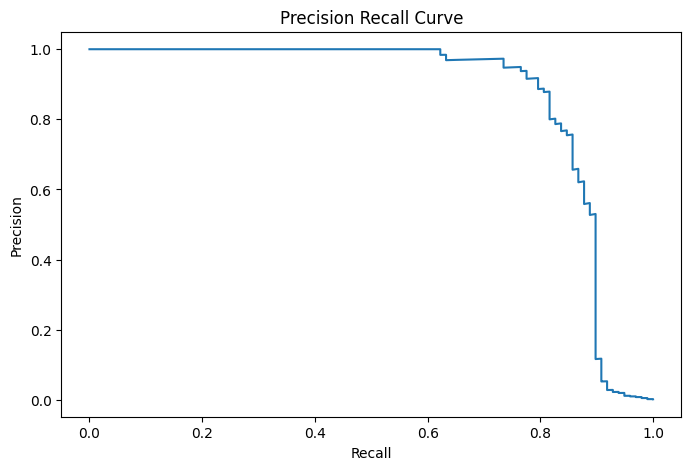

In [28]:
# Precision recall curve
''' The Precision-Recall Curve illustrates the trade-off between fraud detection capability (Recall) and false-positive reduction (Precision) 
across different classification thresholds. A higher area under the Precision-Recall Curve indicates a better ability to identify 
fraudulent transactions while minimizing unnecessary investigations.'''

precision, recall, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [29]:
# ============================================================================
# FEATURE IMPORTANCE(XGBOOST)
# ============================================================================
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':
    xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(
    importance.head(15)
)

   Feature  Importance
14     V14    0.382384
10     V10    0.192604
12     V12    0.055538
4       V4    0.048429
8       V8    0.033117
17     V17    0.020963
13     V13    0.018832
18     V18    0.018224
3       V3    0.017120
26     V26    0.015599
1       V1    0.014482
29  Amount    0.012836
0     Time    0.011906
7       V7    0.011743
20     V20    0.011712


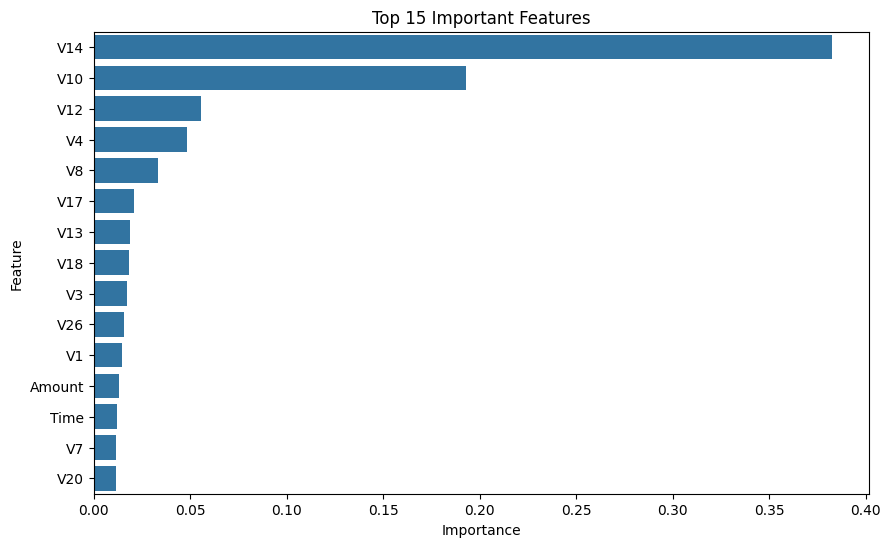

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")
plt.show()

In [31]:
# ============================================================================
# FRAUD RISK SCORE
# ============================================================================
risk_score = (
    xgb_prob * 100
).astype(int)

fraud_results = X_test.copy()

fraud_results['Actual'] = y_test.values

fraud_results['Fraud_Probability'] = xgb_prob

fraud_results['Risk_Score'] = risk_score

fraud_results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual,Fraud_Probability,Risk_Score
263020,1.387182,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.259954,0,0.000371,0
11378,-1.580138,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.304426,0,0.000015,0
147283,-0.138120,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.048286,0,0.000260,0
219439,0.986536,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.347741,0,0.000014,0
36939,-1.182272,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.345707,0,0.001023,0


In [32]:
# ============================================================================
# RISK CATEGORIES
# ============================================================================
def risk_band(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"

fraud_results['Risk_Level'] = (
    fraud_results['Risk_Score']
    .apply(risk_band)
)

fraud_results[
    ['Fraud_Probability',
     'Risk_Score',
     'Risk_Level']
].head()

,Fraud_Probability,Risk_Score,Risk_Level
263020,0.000371,0,Low
11378,0.000015,0,Low
147283,0.000260,0,Low
219439,0.000014,0,Low
36939,0.001023,0,Low


In [33]:
# ============================================================================
# Tableau Input data preparation
# ============================================================================
fraud_dashboard = X_test.copy()

fraud_dashboard['Actual_Class'] = y_test

fraud_dashboard['Predicted_Class'] = xgb_pred

fraud_dashboard['Fraud_Probability'] = xgb_prob

fraud_dashboard['Risk_Score'] = (
    xgb_prob * 100
).round()

In [34]:
# Create Risk Levels
def risk_level(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"

fraud_dashboard['Risk_Level'] = (
    fraud_dashboard['Risk_Score']
    .apply(risk_level)
)

In [35]:
# Create Business Impact Columns
fraud_dashboard['Outcome'] = np.where(
    (fraud_dashboard['Actual_Class']==1) &
    (fraud_dashboard['Predicted_Class']==1),
    'Fraud Detected',

    np.where(
        (fraud_dashboard['Actual_Class']==1) &
        (fraud_dashboard['Predicted_Class']==0),
        'Fraud Missed',

        np.where(
            (fraud_dashboard['Actual_Class']==0) &
            (fraud_dashboard['Predicted_Class']==1),
            'False Alarm',
            'Legitimate'
        )
    )
)

In [36]:
# Add Transaction ID
fraud_dashboard.reset_index(
    inplace=True
)

fraud_dashboard.rename(
    columns={'index':'Transaction_ID'},
    inplace=True
)

In [37]:
fraud_dashboard['Original_Time'] = (
    df.loc[
        fraud_dashboard['Transaction_ID'],
        'Time'
    ].values
)

fraud_dashboard['Original_Amount'] = (
    df.loc[
        fraud_dashboard['Transaction_ID'],
        'Amount'
    ].values
)

In [38]:
fraud_dashboard.head()

,Transaction_ID,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V28,Amount,Actual_Class,Predicted_Class,Fraud_Probability,Risk_Score,Risk_Level,Outcome,Original_Time,Original_Amount
0,263020,1.387182,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,...,0.291319,-0.259954,0,0,0.000371,0.0,Low,Legitimate,160760.0,23.00
1,11378,-1.580138,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,...,-0.511938,-0.304426,0,0,0.000015,0.0,Low,Legitimate,19847.0,11.85
2,147283,-0.138120,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,...,0.509764,-0.048286,0,0,0.000260,0.0,Low,Legitimate,88326.0,76.07
3,219439,0.986536,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,...,-0.060077,-0.347741,0,0,0.000014,0.0,Low,Legitimate,141734.0,0.99
4,36939,-1.182272,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,...,0.104527,-0.345707,0,0,0.001023,0.0,Low,Legitimate,38741.0,1.50


In [39]:
# Export
path =  r"~\Data_Proj\Fraud_Risk_Dashboard.csv"
fraud_dashboard.to_csv(
    path,
    index=False
)

Summary: The project was developed using a historical credit card transaction dataset. Real-time fraud scoring was simulated by applying the trained model to unseen test transactions and generating fraud risk scores from the model's predicted probabilities. The same approach can be extended to real-time transaction streams in a production environment.Executive Fraud Overview Tableau Report is developed by using fraud_dashboard data.